# **Transaction Anomaly Detection**

## **Project Overview**
This project focuses on detecting anomalies in financial transactions using **Isolation Forest**, 
a machine learning algorithm for anomaly detection. The dataset contains details of transactions, 
including transaction amount, frequency, time of day, and user demographics.

### **Objective**
- Identify suspicious transactions that deviate significantly from normal behavior.
- Use **data visualization** and **machine learning** to classify anomalies.
- Implement an interactive system where users can input transaction details to check for anomalies.

---

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import plotly.io as pio
import shap

# Comment the following line to change the default renderer
pio.renderers.default = "png"

## 1. Data Exploration

First, we load the dataset and explore its structure. This helps us understand the features 
and check for missing values.

In [2]:
data = pd.read_csv("data/transaction_anomalies_dataset.csv")
data.head()

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type
0,TX0,1024.835708,3,997.234714,12,29,Friday,06:00,36,Male,1436074,Savings
1,TX1,1013.952065,4,1020.210306,7,22,Friday,01:00,41,Female,627069,Savings
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings
4,TX4,998.777241,1,1007.111026,7,7,Friday,08:00,56,Female,649457,Savings


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               1000 non-null   object 
 1   Transaction_Amount           1000 non-null   float64
 2   Transaction_Volume           1000 non-null   int64  
 3   Average_Transaction_Amount   1000 non-null   float64
 4   Frequency_of_Transactions    1000 non-null   int64  
 5   Time_Since_Last_Transaction  1000 non-null   int64  
 6   Day_of_Week                  1000 non-null   object 
 7   Time_of_Day                  1000 non-null   object 
 8   Age                          1000 non-null   int64  
 9   Gender                       1000 non-null   object 
 10  Income                       1000 non-null   int64  
 11  Account_Type                 1000 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB
None


In [4]:
print(data.describe())

       Transaction_Amount  Transaction_Volume  Average_Transaction_Amount  \
count         1000.000000         1000.000000                 1000.000000   
mean          1038.122511            2.498000                 1000.682506   
std            283.580055            1.115006                   20.632334   
min            849.024392            1.000000                  939.081423   
25%            966.028796            1.000000                  986.800556   
50%           1002.118678            3.000000                 1000.501902   
75%           1033.143657            3.000000                 1015.155595   
max           3227.459108            4.000000                 1073.154036   

       Frequency_of_Transactions  Time_Since_Last_Transaction          Age  \
count                1000.000000                  1000.000000  1000.000000   
mean                   12.078000                    15.341000    40.641000   
std                     4.245225                     8.361258    13.8199

In [5]:
data['hour'] = pd.to_datetime(data['Time_of_Day'], format='%H:%M').dt.hour

In [6]:
# Log transform the Transaction_Amount to reduce skewness
data['log_transaction_amount'] = np.log1p(data['Transaction_Amount'])
data['log_average_transaction_amount'] = np.log1p(data['Average_Transaction_Amount'])
data['log_income'] = np.log1p(data['Income'])

In [7]:
freq_encode_account = data['Account_Type'].value_counts(normalize=True)
data['freq_encoded_account_type'] = data['Account_Type'].map(freq_encode_account)

In [8]:
data

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type,hour,log_transaction_amount,log_average_transaction_amount,log_income,freq_encoded_account_type
0,TX0,1024.835708,3,997.234714,12,29,Friday,06:00,36,Male,1436074,Savings,6,6.933263,6.905988,14.177424,0.484
1,TX1,1013.952065,4,1020.210306,7,22,Friday,01:00,41,Female,627069,Savings,1,6.922597,6.928744,13.348813,0.484
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings,21,6.879311,6.898206,13.575008,0.484
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings,14,6.948727,6.877835,13.335911,0.484
4,TX4,998.777241,1,1007.111026,7,7,Friday,08:00,56,Female,649457,Savings,8,6.907532,6.915834,13.383893,0.484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,TX995,901.138758,3,976.363229,17,19,Monday,05:00,46,Female,424746,Savings,5,6.804768,6.884858,12.959249,0.484
996,TX996,928.962516,4,1028.292292,10,25,Wednesday,09:00,58,Female,908278,Current,9,6.835144,6.936627,13.719307,0.516
997,TX997,950.921600,2,1022.823424,13,28,Friday,02:00,58,Female,1353498,Current,2,6.858483,6.931299,14.118204,0.516
998,TX998,933.291962,4,994.325450,10,8,Tuesday,04:00,58,Female,359072,Savings,4,6.839789,6.903070,12.791281,0.484


## 2. Data Visualization

We analyze the distribution of transaction amounts and their relationships with other features.

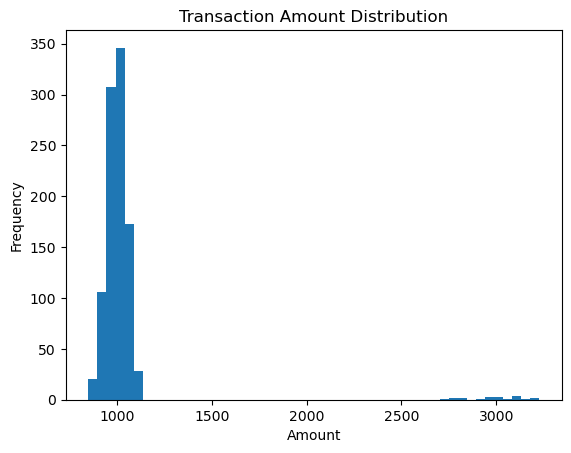

In [9]:
plt.hist(data['Transaction_Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

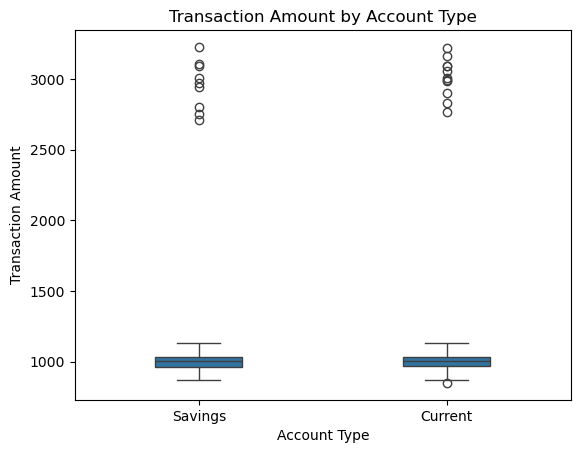

In [10]:
sns.boxplot(y=data['Transaction_Amount'], x=data['Account_Type'], width=0.5, gap=0.3)
plt.xlabel('Account Type')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount by Account Type')
plt.show()

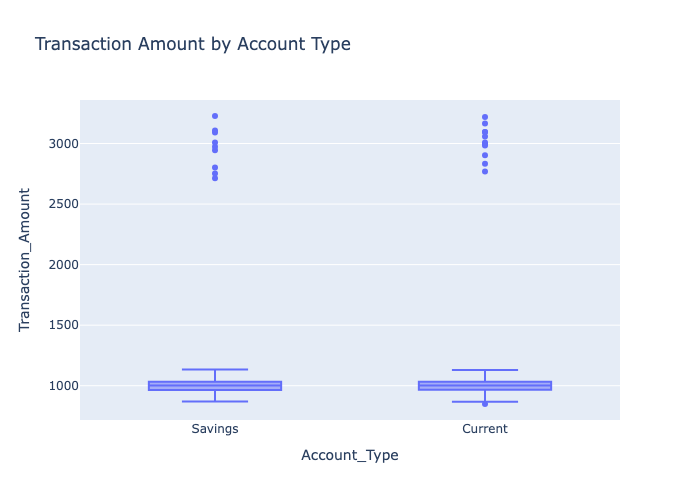

In [11]:
# Transaction Amount by Account Type
fig_box_amount = px.box(data,
                        x='Account_Type',
                        y='Transaction_Amount',
                        title='Transaction Amount by Account Type')
fig_box_amount.show()

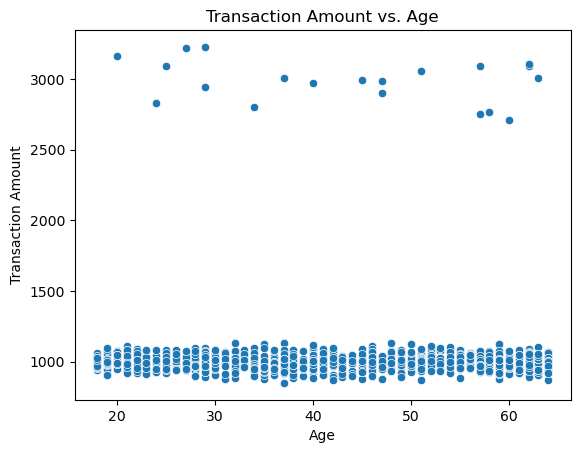

In [12]:
# Average Transaction Amount vs. Age
sns.scatterplot(data=data, x='Age', y='Transaction_Amount')
plt.title('Transaction Amount vs. Age')
plt.xlabel('Age')
plt.ylabel('Transaction Amount')
plt.show()

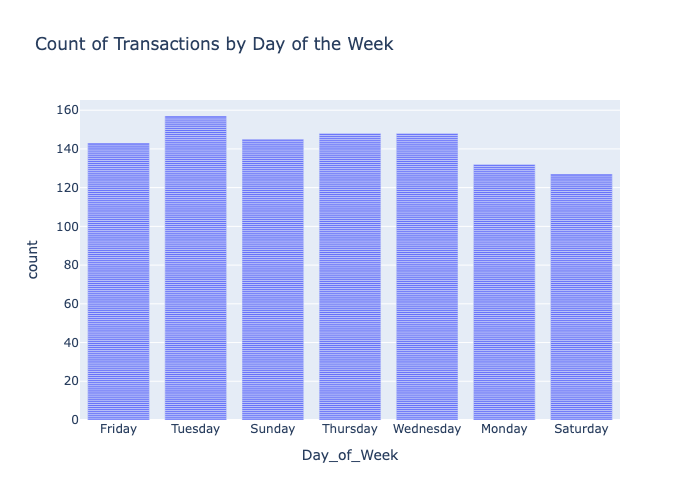

In [13]:
# Count of Transactions by Day of the Week
fig_day_of_week = px.bar(data, x='Day_of_Week',
                         title='Count of Transactions by Day of the Week')
fig_day_of_week.show()

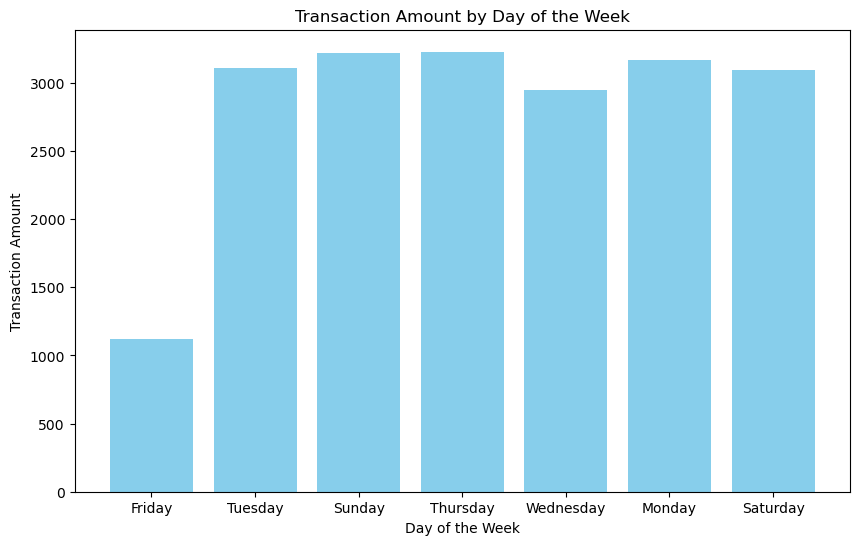

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(data['Day_of_Week'], height=data['Transaction_Amount'], color='skyblue')
plt.title('Transaction Amount by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Transaction Amount')
plt.show()

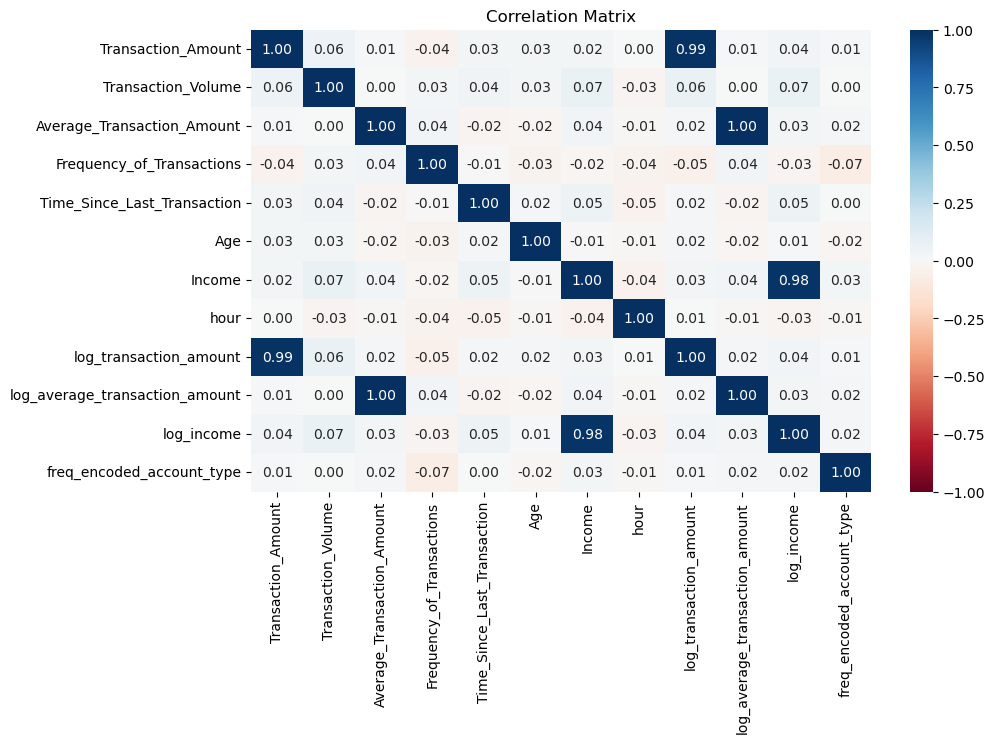

In [15]:
correlation_matrix = data.select_dtypes(include='number').corr()

# PLot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

## Scaling features

In [16]:
features = [
    'log_transaction_amount',
    'log_average_transaction_amount',
    'log_income',
    'hour',
    'freq_encoded_account_type',
    'Time_Since_Last_Transaction'
]

X = data[features]

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Model Training (Isolation Forest)

We use **Isolation Forest** to detect anomalies. Before training, we balance the dataset using **SMOTE**.

In [25]:
model = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)

IsolationForest(contamination=0.02, n_estimators=300, n_jobs=-1,
                random_state=42)

## 5. Model Evaluation

In [26]:
data['anomaly_score'] = -model.decision_function(X_scaled) # higher scores indicate more anomalous transactions

In [27]:
threshold = np.percentile(data['anomaly_score'], 98) # top 2% as anomalies
data['is_anomaly'] = data['anomaly_score'] > threshold

In [28]:
anomalies = data[data['is_anomaly']]
anomalies.sort_values('anomaly_score', ascending=False).head(10)

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type,hour,log_transaction_amount,log_average_transaction_amount,log_income,freq_encoded_account_type,Is_Anomaly,anomaly_score,is_anomaly
724,TX724,2903.890238,4,1073.154036,10,18,Thursday,19:00,47,Female,905556,Current,19,7.974151,6.979289,13.716306,0.516,True,0.049833,True
878,TX878,2982.897583,3,972.379854,5,26,Saturday,19:00,47,Male,551666,Current,19,8.000986,6.880774,13.220700,0.516,True,0.042076,True
422,TX422,3218.959781,1,965.597949,15,23,Sunday,09:00,27,Female,1002495,Current,9,8.077124,6.873783,13.818003,0.516,True,0.036275,True
570,TX570,2973.267078,2,972.715045,5,27,Monday,08:00,40,Male,1427113,Savings,8,7.997753,6.881119,14.171165,0.484,True,0.033304,True
230,TX230,2752.637650,4,1020.914703,11,13,Saturday,03:00,57,Male,1460932,Savings,3,7.920678,6.929433,14.194586,0.484,True,0.026976,True
575,TX575,2713.596587,1,1026.366046,15,26,Saturday,11:00,60,Female,1240335,Savings,11,7.906399,6.934754,14.030893,0.484,True,0.025810,True
869,TX869,3108.424034,3,1002.235983,9,21,Tuesday,04:00,62,Female,687932,Savings,4,8.042193,6.910986,13.441447,0.484,True,0.025519,True
991,TX991,3091.310338,2,988.857389,14,16,Thursday,00:00,25,Male,912236,Savings,0,8.036674,6.897561,13.723655,0.484,True,0.025320,True
936,TX936,2833.966439,3,1039.255925,10,12,Tuesday,17:00,24,Female,1018960,Current,17,7.949785,6.947222,13.834294,0.516,True,0.022051,True
59,TX59,2769.890232,3,1007.261392,17,23,Monday,02:00,58,Male,1198320,Current,2,7.926924,6.915983,13.996432,0.516,True,0.018375,True


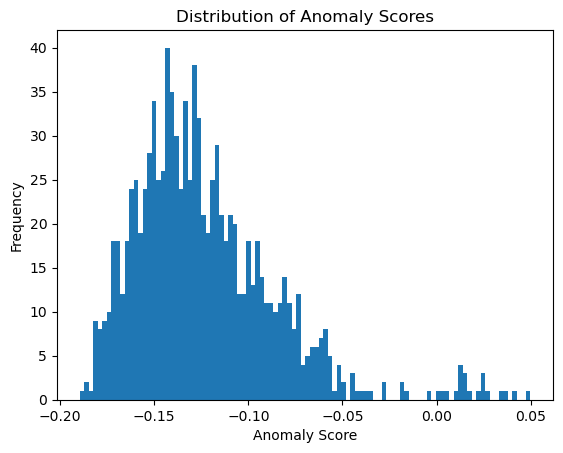

In [29]:
plt.hist(data['anomaly_score'], bins=100)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()

In [30]:
# Optional Top-k approach instead of thresholding
top_k = 100
top_anomalies = data.nlargest(top_k, 'anomaly_score')

In [31]:
top_anomalies

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type,hour,log_transaction_amount,log_average_transaction_amount,log_income,freq_encoded_account_type,Is_Anomaly,anomaly_score,is_anomaly
724,TX724,2903.890238,4,1073.154036,10,18,Thursday,19:00,47,Female,905556,Current,19,7.974151,6.979289,13.716306,0.516,True,0.049833,True
878,TX878,2982.897583,3,972.379854,5,26,Saturday,19:00,47,Male,551666,Current,19,8.000986,6.880774,13.220700,0.516,True,0.042076,True
422,TX422,3218.959781,1,965.597949,15,23,Sunday,09:00,27,Female,1002495,Current,9,8.077124,6.873783,13.818003,0.516,True,0.036275,True
570,TX570,2973.267078,2,972.715045,5,27,Monday,08:00,40,Male,1427113,Savings,8,7.997753,6.881119,14.171165,0.484,True,0.033304,True
230,TX230,2752.637650,4,1020.914703,11,13,Saturday,03:00,57,Male,1460932,Savings,3,7.920678,6.929433,14.194586,0.484,True,0.026976,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,TX744,998.884986,1,986.222289,9,26,Saturday,21:00,30,Male,325938,Current,21,6.907640,6.894895,12.694466,0.516,False,-0.074998,False
37,TX37,1030.306468,3,961.115408,7,28,Monday,19:00,38,Male,568246,Savings,19,6.938582,6.869134,13.250311,0.484,False,-0.075177,False
753,TX753,945.068979,2,1028.410086,10,4,Friday,00:00,24,Female,836119,Savings,0,6.852315,6.936741,13.636527,0.484,False,-0.075389,False
705,TX705,1025.678421,4,1037.340742,5,1,Tuesday,18:00,64,Female,699017,Savings,18,6.934084,6.945379,13.457432,0.484,False,-0.075409,False


In [32]:
data

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type,hour,log_transaction_amount,log_average_transaction_amount,log_income,freq_encoded_account_type,Is_Anomaly,anomaly_score,is_anomaly
0,TX0,1024.835708,3,997.234714,12,29,Friday,06:00,36,Male,1436074,Savings,6,6.933263,6.905988,14.177424,0.484,False,-0.110504,False
1,TX1,1013.952065,4,1020.210306,7,22,Friday,01:00,41,Female,627069,Savings,1,6.922597,6.928744,13.348813,0.484,False,-0.127738,False
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings,21,6.879311,6.898206,13.575008,0.484,False,-0.149396,False
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings,14,6.948727,6.877835,13.335911,0.484,False,-0.107558,False
4,TX4,998.777241,1,1007.111026,7,7,Friday,08:00,56,Female,649457,Savings,8,6.907532,6.915834,13.383893,0.484,False,-0.160370,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,TX995,901.138758,3,976.363229,17,19,Monday,05:00,46,Female,424746,Savings,5,6.804768,6.884858,12.959249,0.484,False,-0.083480,False
996,TX996,928.962516,4,1028.292292,10,25,Wednesday,09:00,58,Female,908278,Current,9,6.835144,6.936627,13.719307,0.516,False,-0.137109,False
997,TX997,950.921600,2,1022.823424,13,28,Friday,02:00,58,Female,1353498,Current,2,6.858483,6.931299,14.118204,0.516,False,-0.094472,False
998,TX998,933.291962,4,994.325450,10,8,Tuesday,04:00,58,Female,359072,Savings,4,6.839789,6.903070,12.791281,0.484,False,-0.090370,False


In [33]:
original_data = pd.read_csv("data/supervised_transaction_anomalies_dataset.csv")
original_data.head()

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type
0,TX0,1024.835708,3,997.234714,12,29,Friday,06:00,36,Male,1436074,Savings
1,TX1,1013.952065,4,1020.210306,7,22,Friday,01:00,41,Female,627069,Savings
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings
4,TX4,998.777241,1,1007.111026,7,7,Friday,08:00,56,Female,649457,Savings


In [34]:
new_data = original_data.join(data.set_index('Transaction_ID')['is_anomaly'], on='Transaction_ID')

In [37]:
# save csv
new_data.to_csv("data/supervised_transaction_anomalies_dataset.csv", index=False)